In [ ]:
import struct
import sys
import torchvision
import torch
import json
from array import array
from os import path

train_dataset = torchvision.datasets.MNIST(root='/content/sample_data/', train=True, download=True)
test_dataset = torchvision.datasets.MNIST(root='/content/sample_data/', train=False, download=True)

In [ ]:
import os
import struct
import numpy as np
from array import array
from os import path
from PIL import Image

def read(dataset):
    if dataset == "training":
        path_img = "/content/sample_data/MNIST/raw/train-images-idx3-ubyte"
        path_lbl = "/content/sample_data/MNIST/raw/train-labels-idx1-ubyte"
    elif dataset == "testing":
        path_img = "/content/sample_data/MNIST/raw/t10k-images-idx3-ubyte"
        path_lbl = "/content/sample_data/MNIST/raw/t10k-labels-idx1-ubyte"
    else:
        raise ValueError("dataset must be 'testing' or 'training'")

    with open(path_lbl, 'rb') as f_label:
        _, size = struct.unpack(">II", f_label.read(8))
        lbl = array("B", f_label.read())

    with open(path_img, 'rb') as f_img:
        _, size, rows, cols = struct.unpack(">IIII", f_img.read(16))
        img = array("B", f_img.read())

    return lbl, img, size, rows, cols


def write_dataset(labels, data, size, rows, cols, output_dir):
    # создаём папки class_0 ... class_9
    for c in range(10):
        os.makedirs(path.join(output_dir, f"class_{c}"), exist_ok=True)

    # весь массив пикселей -> [size, rows, cols]
    imgs = np.frombuffer(data, dtype=np.uint8).reshape(size, rows, cols)

    # каждую картинку сохраняем в папку её класса
    for i, label in enumerate(labels):
        out = path.join(output_dir, f"class_{label}", f"{i}.png")
        Image.fromarray(imgs[i]).save(out)


output_path = "/content/mnist"

for dataset in ["training", "testing"]:
    write_dataset(*read(dataset), path.join(output_path, dataset))

In [ ]:
if not os.path.isdir("dataset"):
    os.mkdir("dataset")

img = np.random.randint(0, 50, [100000, 64, 64], dtype=np.uint8)
square = np.random.randint(100, 200, [100000, 15, 15], dtype=np.uint8)

coords = np.empty([100000, 2])

data = {}

for i in range(img.shape[0]):

    x = np.random.randint(20, 44)
    y = np.random.randint(20, 44)

    img[i,(y-7):(y +8), (x -7):(x + 8)] = square[i]

    coords[i] = [y, x]

    name_img = f'img_{i}.jpeg'
    path_img = os.path. join('dataset/', name_img)

    image = Image. fromarray(img[i])
    image. save(path_img)

    data[name_img] = [y, x]

with open('dataset/coords.json', 'w') as f:
    json.dump(data, f, indent=2)

# os.rmdir('dataset/.ipynb_checkpoints')

### Остановка в обучении

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

import torchvision
from torchvision.transforms import v2

import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, MultipleLocator

import json
from tqdm import tqdm
from PIL import Image

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [ ]:
class MNISTDataset(Dataset):
    def __init__(self,path,transform=None):
        self.path = path
        self.transform = transform

        self.len_dataset=0
        self.data_list=[]

        for path_dir, dir_list, file_list in os.walk(path): #путь папки, вложенные папки и файлы
            if path_dir == path:
                self.classes = dir_list
                self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}
                continue

            cls = os.path.basename(path_dir) # Имя последней папки/файла из пути

            for name_file in file_list:
                file_path = os.path.join(path_dir, name_file) #объединяет путь к папке и имя файла в один путь к файлу
                self.data_list.append((file_path, self.class_to_idx[cls])) #добавляет пару «путь к файлу и числовой индекс его класса»

            self.len_dataset += len(file_list)

    def __len__(self):
        return self.len_dataset

    def __getitem__(self, index):
        file_path, target = self.data_list[index]
        sample = np.array(Image.open(file_path))

        if self.transform is not None:
            sample = self.transform(sample)

        return sample, target

In [ ]:
transform = v2.Compose(
    [
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize(mean=(0.5,),std=(0.5,))
    ]
)

In [ ]:
train = MNISTDataset('/content/mnist/training', transform=transform)
test = MNISTDataset(r'/content/mnist/testing', transform=transform)

In [ ]:
train, val = random_split(train, [0.7,0.3])

In [ ]:
train_loader = DataLoader(train, 64, True)
val_loader = DataLoader(val, 64, False)
test_loader = DataLoader(test, 64, False)

### Добавление dropout

dropout - это метод регуляризации нейросетей, в котором на каждом шаге обучения каждый нейрон независимо выключается (его выход обнуляется) с вероятностью p. Сеть каждый раз обучается как случайная подсеть, поэтому нейроны не могут опираться на конкретных соседей и учат более устойчивые признаки, в результате чего уменьшается переобучение

### Добавление BatchNorm

BatchNorm - это метод, который нормализует выходы слоя для каждого мини-батча, ускоряя и стабилизируя процесс обучения

In [ ]:
class MyModel(nn.Module):
    def __init__(self, input, output):
        super().__init__()
        self.layer_1 = nn.Linear(input, 128), #bias=False)
        self.layer_2 = nn.Linear(128, output)
        self.dropout = nn.Dropout(0.5) # слой dropout с вероятностью отключения 0.5
        self.batchnorm = nn.BatchNorm1d(128) # 1d для таблиц/временных рядов,
        # 2d для двумерных пространственных данных, 3d для трехмерных пространственных данных
        self.act = nn.ReLU()

    def forward(self, x):
        x = self.layer_1(x)
        x = self.batchnorm(x) # batchnorm НЕ рекомендуется использовать вместе с dropout
        x = self.act(x)
        x = self.dropout(x) # применение dropout
        out = self.layer_2(x)
        return out

model = MyModel(784, 10).to(device)

In [ ]:
input = torch.rand([16,784], dtype=torch.float32).to(device)
out = model(input)
out.shape

torch.Size([16, 10])

In [ ]:
loss_model = nn.CrossEntropyLoss()
opt = torch.optim.Adam(model.parameters(), lr=0.001)
lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=5)

In [ ]:
EPOCHS = 100

train_loss = []
val_loss = []
train_acc = []
val_acc = []
lr_list = []
best_loss = None
count = 0 # число операций без улучшения модели

In [ ]:
for epoch in range(EPOCHS):

    model.train()
    running_train_loss = []
    true_answer = 0
    train_loop = tqdm(train_loader, leave=False)
    for x, targets in train_loop:
        # (batch_size, 1, 28*28) -> (batch_size, 784)
        x = x.reshape(-1,28*28).to(device)
        # (batch_size, int) -> (batch_size, 10), dtype=float32
        targets = targets.reshape(-1).to(torch.int32)
        targets = torch.eye(10)[targets].to(device)

        # Прямой проход + ошибка
        pred = model(x)
        loss = loss_model(pred, targets)

        # Обратный проход
        opt.zero_grad()
        loss.backward()

        # Шаг оптимизации
        opt.step()

        # Добавление значения ф-ии потерь в список
        running_train_loss.append(loss.item())
        mean_train_loss = sum(running_train_loss)/len(running_train_loss)
        true_answer += (pred.argmax(dim=1) == targets.argmax(dim=1)).sum().item()
        # Доп информация
        train_loop.set_description(f'Epoch: [{epoch+1}/{EPOCHS}], train_loss: {mean_train_loss:.4f}')

    # Расчет значения метрики
    running_train_acc = true_answer/len(train)
    # Сохрание значений ф-им потерь и метрики
    train_loss.append(mean_train_loss)
    train_acc.append(running_train_acc)


    # Проверка модели(валидация)
    model.eval()
    with torch.no_grad(): # Запрещаем вычисление градиентов в цикле
        running_val_loss = []
        true_answer = 0
        for x, targets in val_loader:
            x = x.reshape(-1, 28*28).to(device)

            targets = targets.reshape(-1).to(torch.int32)
            targets = torch.eye(10)[targets].to(device)

            # Прямой проход + ошибка
            pred = model(x)
            loss = loss_model(pred, targets)

            # Добавление значения ф-ии потерь в список
            running_val_loss.append(loss.item())
            mean_val_loss = sum(running_val_loss)/len(running_val_loss)

            true_answer += (pred.argmax(dim=1) == targets.argmax(dim=1)).sum().item()
        # Расчет значения метрики
        running_val_acc = true_answer / len(val)

        # Сохрание значений ф-им потерь и метрики
        val_loss.append(mean_val_loss)
        val_acc.append(running_val_acc)

        print(f'Epoch: [{epoch+1}/{EPOCHS}], train_loss: {mean_train_loss:.4f}, train_acc: {running_train_acc:.4f}, val_loss: {mean_val_loss:.4f}, val_acc: {running_val_acc:.4f}')

        if best_loss is None:
            best_loss = mean_val_loss

        if mean_val_loss < best_loss:
            best_loss = mean_val_loss
            count = 0

            checkpoint = {
                'state_model': model.state_dict(),
                'state_opt': opt.state_dict(),
                'state_lr_scheduler': lr_scheduler.state_dict(),
                'loss': {
                    'train_loss': train_loss,
                    'val_loss': val_loss,
                    'best_loss': best_loss
                },
                'metric':{
                    'train_acc': train_acc,
                    'val_acc': val_acc
                },
                'lr': lr_list,
                'epoch':{
                    'EPOCHS': EPOCHS,
                    'save_epoch': epoch
                }
            }

            torch.save(model.state_dict(), f'model_state_dict_epoch_{epoch+1}.pt')
            print(f'На эпохе {epoch+1} сохранена модель со значением ф-ии потерь на валидации: {mean_val_loss:.4f}', end='\n\n')
        if count >= 10:
            print(f'\nОбучение остановлено на эпохе {epoch+1}')
            break

        count += 1

Epoch: [1/50], train_loss: 0.4283, train_acc: 0.8759, val_loss: 0.2856, val_acc: 0.9177


Epoch: [2/50], train_loss: 0.2389, train_acc: 0.9298, val_loss: 0.2257, val_acc: 0.9335
На эпохе 2 сохранена модель со значением ф-ии потерь на валидации: 0.2257



Epoch: [3/50], train_loss: 0.1851, train_acc: 0.9445, val_loss: 0.1871, val_acc: 0.9468
На эпохе 3 сохранена модель со значением ф-ии потерь на валидации: 0.1871



Epoch: [4/50], train_loss: 0.1479, train_acc: 0.9557, val_loss: 0.1674, val_acc: 0.9508
На эпохе 4 сохранена модель со значением ф-ии потерь на валидации: 0.1674



Epoch: [5/50], train_loss: 0.1225, train_acc: 0.9631, val_loss: 0.1570, val_acc: 0.9537
На эпохе 5 сохранена модель со значением ф-ии потерь на валидации: 0.1570



...

Epoch: [19/50], train_loss: 0.0324, train_acc: 0.9892, val_loss: 0.1271, val_acc: 0.9675


Epoch: [20/50], train_loss: 0.0308, train_acc: 0.9896, val_loss: 0.1197, val_acc: 0.9681


Epoch: [21/50], train_loss: 0.0297, train_acc: 0.9896, val_loss: 0.1179, val_acc: 0.9710


Epoch: [22/50], train_loss: 0.0274, train_acc: 0.9906, val_loss: 0.1262, val_acc: 0.9680


Epoch: [23/50], train_loss: 0.0253, train_acc: 0.9912, val_loss: 0.1378, val_acc: 0.9654

Обучение остановлено на эпохе 23


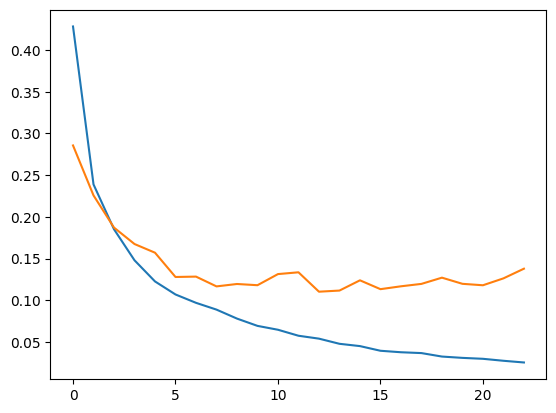

In [ ]:
plt.plot(train_loss)
plt.plot(val_loss)

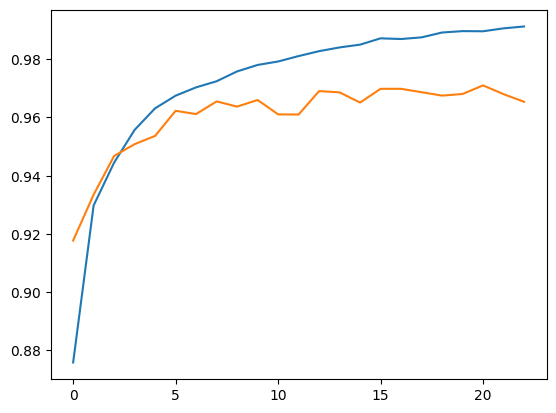

In [ ]:
plt.plot(train_acc)
plt.plot(val_acc)